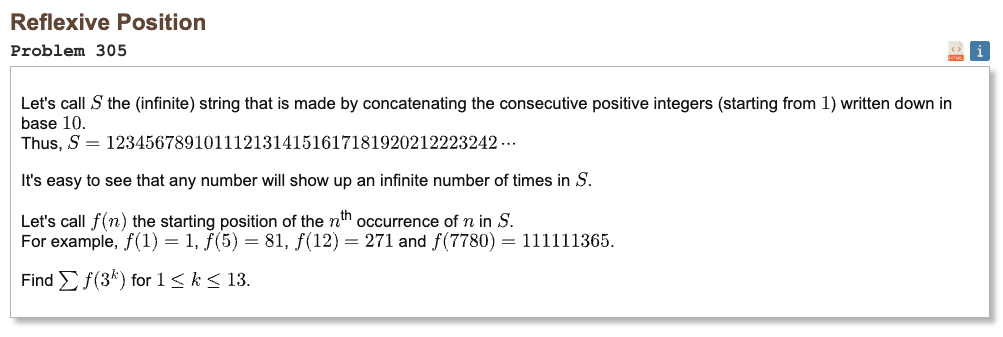

## Initial approach

* build the infinite string conceptually, but never actually create it
* for a given number limit, count how many times the target text starts before or inside that limit
* use binary search to find the number where the wanted occurrence first appears
* handle short digit lengths by direct checking because they are small enough
* handle longer digit lengths with counting rules instead of scanning every number
* after binary search, check only the final number area to get the exact starting position
* repeat this for powers of 3 and add the positions

In [1]:
from bisect import bisect_right

def digits_before_number(x):
    d = len(str(x))
    total = 0
    for k in range(1, d):
        total += 9 * 10 ** (k - 1) * k
    total += (x - 10 ** (d - 1)) * d
    return total

def count_pattern_in_range_inside(lo, hi, d, offset, pattern_value, pattern_len):
    unit = 10 ** (d - offset - pattern_len)
    block = unit * 10 ** pattern_len
    start = pattern_value * unit

    def count_upto(x):
        if x < 0:
            return 0
        q, r = divmod(x + 1, block)
        return q * unit + max(0, min(r - start, unit))

    return count_upto(hi) - count_upto(lo - 1)

def count_ap(lo, hi, mod, rem):
    if lo > hi:
        return 0
    first = lo + ((rem - lo) % mod)
    if first > hi:
        return 0
    return (hi - first) // mod + 1

def transition_matches(x, s):
    d = len(str(x))
    text = ""
    y = x
    while len(text) < d + len(s):
        text += str(y)
        y += 1
    out = []
    for offset in range(d):
        if text[offset:offset + len(s)] == s:
            out.append(offset)
    return out

def build_small_occurrences(s):
    pattern_len = len(s)
    data = {}
    for d in range(1, pattern_len):
        lo = 1 if d == 1 else 10 ** (d - 1)
        hi = 10 ** d - 1
        values = []
        for x in range(lo, hi + 1):
            for offset in transition_matches(x, s):
                values.append(x)
        values.sort()
        data[d] = values
    return data

def count_starts_up_to(x, s, small_data):
    if x <= 0:
        return 0

    pattern_len = len(s)
    pattern_value = int(s)
    max_d = len(str(x))
    total = 0

    for d in range(1, max_d + 1):
        lo = 1 if d == 1 else 10 ** (d - 1)
        hi = min(x, 10 ** d - 1)

        if hi < lo:
            continue

        if d < pattern_len:
            values = small_data.get(d, [])
            total += bisect_right(values, hi)
            continue

        normal_hi = min(hi, 10 ** d - 2)

        if normal_hi >= lo:
            for offset in range(d):
                if offset + pattern_len <= d:
                    total += count_pattern_in_range_inside(
                        lo, normal_hi, d, offset, pattern_value, pattern_len
                    )
                else:
                    left_len = d - offset
                    right_len = pattern_len - left_len

                    left_text = s[:left_len]
                    right_text = s[left_len:]

                    left_value = int(left_text)
                    right_value = int(right_text)

                    suffix_mod = 10 ** left_len
                    prefix_scale = 10 ** (d - right_len)

                    a = right_value * prefix_scale - 1
                    b = (right_value + 1) * prefix_scale - 2

                    low = max(lo, a)
                    high = min(normal_hi, b)

                    total += count_ap(low, high, suffix_mod, left_value)

        if hi == 10 ** d - 1:
            total += len(transition_matches(hi, s))

    return total

def f(n):
    s = str(n)
    small_data = build_small_occurrences(s)

    lo = 1
    hi = 10

    while count_starts_up_to(hi, s, small_data) < n:
        hi *= 2

    while lo < hi:
        mid = (lo + hi) // 2
        if count_starts_up_to(mid, s, small_data) >= n:
            hi = mid
        else:
            lo = mid + 1

    x = lo
    before = count_starts_up_to(x - 1, s, small_data)
    need = n - before

    offsets = transition_matches(x, s)
    offset = offsets[need - 1]

    return digits_before_number(x) + offset + 1

def solve():
    total = 0
    for k in range(1, 14):
        total += f(3 ** k)
    return total

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 18174995535140
CPU times: user 851 ms, sys: 4.13 ms, total: 855 ms
Wall time: 855 ms
